# 06 — Baseline Model (`Baseline_LASSO` v1.1 on FES v1.1)

**DATSCI7030 · Causal Event-Driven Market Impact Modelling**
Author: Ibrahim Haroun · LJMU 2025–2026 · Version 3.1
Controlled migration 2026-07-14: trains `Baseline_LASSO` v1.1 directly from the validated 92-feature FES v1.1 matrix while reading only its unchanged 27 Market features. The FES v1.0 baseline is retained as an archived comparison, not silently overwritten or relabelled.

---

## Purpose

Train and freeze the market-only baseline (`Baseline_LASSO`) that every event-enhanced model in Notebook 07 must beat on **both** RMSE and directional accuracy to support RQ3 — per `docs/research_bible/model_contract.md` (MCP v1.0) and `baseline_model_specification.md`.

## Inputs

| File | Role |
|------|------|
| `data/processed/feature_matrix.parquet` | FES v1.1, validation `PASS`, read-only — filtered to the 27 Market-category columns |
| `data/processed/feature_profile.json` | Persisted train-split scaling parameters — never refit |
| `docs/research_bible/feature_contract.md` | Baseline Eligibility table — sole authority on which columns this model may read |

## Outputs

| File | Role |
|------|------|
| `models/baseline/baseline_lasso.joblib` | Trained model object |
| `models/baseline/baseline_model_metadata.json` | Hyperparameters, seed, feature list |
| `reports/baseline/baseline_predictions.parquet` | Row-level train+test predictions/residuals |
| `reports/baseline/baseline_metrics.json` | Full SAP v1.0 metric suite, versioned to FES v1.1 |
| `reports/baseline/baseline_model_validation.json` | Machine-readable FES/input/contract/reproduction validation |

**Controlled save rule:** the exact FES v1.0 baseline artefacts are archived before execution. This notebook saves v1.1 only after the feature-matrix contract, hashes, market-only boundary, and expected historical reproduction all pass.

## Research Questions Supported

**RQ3** (primary) — this is the floor every event-enhanced model must clear. Not RQ1/RQ2.

## Pipeline Position

`05_feature_engineering.ipynb` → **`06_model_training.ipynb`** → `07_model_evaluation.ipynb` → `08_results_visualisation.ipynb`.

## Scope — this notebook DOES

- Read `feature_matrix.parquet`, filter to the 27 Market-category columns + `date`/`split`/target
- Apply the persisted train-split scaling parameters (never refit)
- Fit `LassoCV` with `TimeSeriesSplit(5)`, `random_state=42`, exactly per `baseline_model_specification.md`
- Evaluate on train/test using the full frozen metric suite
- Validate the v1.1 model against the dated FES v1.0 baseline archive

## Scope — this notebook does NOT

- Read any Macro, Sentiment, Event, Temporal, or Interaction column (a protocol violation of `statistical_decision_matrix.md` Part K)
- Train any event-enhanced model (Notebook 07's job)
- Modify `feature_matrix.parquet` or any other frozen artefact
- Change the model roster, promotion criteria, or CV discipline frozen in MCP/SAP v1.0

**Target:** `fwd_return_1d`, identical to every model in this project.

In [11]:
import warnings, json, hashlib, platform, sys
from importlib.metadata import version as package_version
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import TimeSeriesSplit
import joblib

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
PROC = ROOT / 'data' / 'processed'
MODELS = ROOT / 'models'
REPORTS = ROOT / 'reports'
(MODELS / 'baseline').mkdir(parents=True, exist_ok=True)
(REPORTS / 'baseline').mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
print(f'ROOT   : {ROOT}')
print(f'PROC   : {PROC}')

ROOT   : /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI
PROC   : /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/data/processed


---
## Section 1 — Load `feature_matrix.parquet` and Scaling Parameters

In [12]:
fm = pd.read_parquet(PROC / 'feature_matrix.parquet')
with open(PROC / 'feature_profile.json') as f:
    profile = json.load(f)

# FES v1.1 restored the unconditional validation gate: downstream training may consume
# the current matrix only when the exact artefact reports PASS and its hashes/version match.
with open(PROC / 'feature_matrix_validation.json') as f:
    fm_validation = json.load(f)

matrix_path = PROC / 'feature_matrix.parquet'
matrix_sha256 = hashlib.sha256(matrix_path.read_bytes()).hexdigest()

assert fm_validation['validation_status'] == 'PASS', 'FES validation must PASS before model training'
assert fm_validation['fes_version'] == '1.1', f'Expected FES v1.1, got {fm_validation.get("fes_version")}'
assert profile['feature_matrix_version'] == '1.1'
assert fm_validation['dataset_version'] == '1.2'
assert fm_validation['feature_count'] == profile['feature_count'] == 92
assert matrix_sha256 == fm_validation['artifact_sha256'] == profile['artifact_sha256']
assert len(fm) == fm_validation['row_count'] == profile['rows']

MARKET_FEATURES = profile['category_membership']['market']
assert len(MARKET_FEATURES) == 27, f'Expected 27 Market features, found {len(MARKET_FEATURES)}'

_market_constant = [c for c in fm_validation.get('constant_columns', []) if c in MARKET_FEATURES]
_market_duplicate = [c for c in fm_validation.get('duplicate_features', []) if c in MARKET_FEATURES]
assert not _market_constant, f'Constant column(s) within the 27 Market features this model reads: {_market_constant}'
assert not _market_duplicate, f'Duplicate column(s) within the 27 Market features this model reads: {_market_duplicate}'

assert set(MARKET_FEATURES).issubset(fm.columns)
print(f'feature_matrix.parquet: FES v1.1, validation PASS, sha256={matrix_sha256}')

TARGET = 'fwd_return_1d'

train = fm[fm['split'] == 'train'].reset_index(drop=True)
test = fm[fm['split'] == 'test'].reset_index(drop=True)
print(f'Train rows: {len(train):,}  Test rows: {len(test):,}')
print(f'Market features (baseline-eligible only): {len(MARKET_FEATURES)}')
print(f'Rows: {len(fm):,} ({len(train):,} train / {len(test):,} test)')

feature_matrix.parquet: FES v1.1, validation PASS, sha256=127a6dbe4b83e59c873dfdf7502060aab115037732bbb723f9d489c6b85dc383
Train rows: 1,727  Test rows: 750
Market features (baseline-eligible only): 27
Rows: 2,477 (1,727 train / 750 test)


---
## Section 2 — Apply Persisted Scaling (train-split mean/std, never refit)

In [13]:
scale_params = profile['scaling']['parameters']
assert all(np.isfinite(scale_params[c]['std']) and scale_params[c]['std'] > 0 for c in MARKET_FEATURES)

def scale(frame, cols):
    out = frame[cols].copy()
    for c in cols:
        out[c] = (out[c] - scale_params[c]['mean']) / scale_params[c]['std']
    return out

X_train = scale(train, MARKET_FEATURES)
X_test = scale(test, MARKET_FEATURES)
y_train = train[TARGET]
y_test = test[TARGET]

assert np.isfinite(X_train.to_numpy()).all() and np.isfinite(X_test.to_numpy()).all()
print(f'X_train: {X_train.shape}   X_test: {X_test.shape}')

X_train: (1727, 27)   X_test: (750, 27)


---
## Section 3 — Train `Baseline_LASSO`

`LassoCV(cv=TimeSeriesSplit(n_splits=5), random_state=42, max_iter=50000, tol=1e-6)` — automatic coordinate-descent alpha-path search, chronological CV throughout (never a shuffled K-fold — this corrects the legacy `src/models.py` gap logged in `10_decision_log.md`).

In [14]:
baseline_lasso = LassoCV(
    cv=TimeSeriesSplit(n_splits=5),
    random_state=RANDOM_SEED,
    max_iter=50000,
    tol=1e-6,
    n_jobs=-1,
)
baseline_lasso.fit(X_train, y_train)

print(f'alpha_selected : {baseline_lasso.alpha_}')
print(f'intercept      : {baseline_lasso.intercept_}')
print(f'n_nonzero_coef : {int(np.sum(baseline_lasso.coef_ != 0))} / {len(MARKET_FEATURES)}')

alpha_selected : 0.0018533887501907256
intercept      : 0.00046584536225195564
n_nonzero_coef : 0 / 27


**Interpretation.** At the CV-selected alpha, all 27 Market-feature coefficients are expected to shrink to exactly zero (`baseline_model_specification.md`'s frozen result) — the fitted model reduces to its intercept alone, i.e. the training-mean return. This is reported exactly as obtained, not adjusted or re-tuned to avoid a null result, per the no-HARKing discipline this Research Bible already applies (`statistical_analysis_plan.md` "Status of this freeze").

---
## Section 4 — Evaluate (full SAP v1.0 metric suite)

In [15]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0
    dir_acc = float(np.mean(np.sign(y_pred) == np.sign(y_true)))
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Dir_Acc': dir_acc}

pred_train = baseline_lasso.predict(X_train)
pred_test = baseline_lasso.predict(X_test)

metrics_train = compute_metrics(y_train.values, pred_train)
metrics_test = compute_metrics(y_test.values, pred_test)

print('TRAIN:', metrics_train)
print('TEST :', metrics_test)

# ── Full SAP v1.0 evaluation suite ─────────────────────────────────────────────
def information_coefficient(y_true, y_pred):
    if np.ptp(np.asarray(y_pred)) == 0:
        return None
    value = pd.Series(y_true).corr(pd.Series(y_pred), method='spearman')
    return float(value) if np.isfinite(value) else None

def direction_metrics(y_true, y_score):
    actual_up = np.asarray(y_true) > 0
    predicted_up = np.asarray(y_score) > 0
    tp = int(np.sum(actual_up & predicted_up)); tn = int(np.sum(~actual_up & ~predicted_up))
    fp = int(np.sum(~actual_up & predicted_up)); fn = int(np.sum(actual_up & ~predicted_up))
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    positives = np.asarray(y_score)[actual_up]; negatives = np.asarray(y_score)[~actual_up]
    auc = float(np.mean((positives[:, None] > negatives).astype(float) +
                        0.5 * (positives[:, None] == negatives)))
    return {'confusion_matrix': {'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn},
            'precision': float(precision), 'recall': float(recall), 'f1': float(f1),
            'accuracy': float((tp + tn) / len(actual_up)), 'roc_auc': auc}

def residual_diagnostics(y_true, y_pred):
    residual = np.asarray(y_true) - np.asarray(y_pred)
    centred = residual - residual.mean(); std0 = centred.std(ddof=0)
    skewness = float(np.mean((centred / std0) ** 3))
    excess_kurtosis = float(np.mean((centred / std0) ** 4) - 3)
    jb = float(len(residual) / 6 * (skewness ** 2 + excess_kurtosis ** 2 / 4))
    dw = float(np.sum(np.diff(residual) ** 2) / np.sum(residual ** 2))
    het_corr = None
    if np.ptp(np.asarray(y_pred)) > 0:
        value = np.corrcoef(np.abs(residual), np.asarray(y_pred))[0, 1]
        het_corr = float(value) if np.isfinite(value) else None
    return {'residual_mean': float(residual.mean()), 'residual_std': float(residual.std(ddof=1)),
            'skewness': skewness, 'excess_kurtosis': excess_kurtosis,
            'durbin_watson': dw, 'jarque_bera_stat': jb,
            'jarque_bera_p': float(np.exp(-jb / 2)), 'het_corr': het_corr}

def block_bootstrap_rmse_ci(y_true, y_pred, block_length=21, n_boot=2000, seed=42):
    errors = np.asarray(y_true) - np.asarray(y_pred); n = len(errors)
    rng = np.random.default_rng(seed); values = np.empty(n_boot)
    blocks_needed = int(np.ceil(n / block_length))
    for i in range(n_boot):
        starts = rng.integers(0, n, size=blocks_needed)
        idx = np.concatenate([(np.arange(s, s + block_length) % n) for s in starts])[:n]
        values[i] = np.sqrt(np.mean(errors[idx] ** 2))
    lower, upper = np.quantile(values, [0.025, 0.975])
    return {'rmse_95ci_lower': float(lower), 'rmse_95ci_upper': float(upper),
            'block_length': block_length, 'n_boot': n_boot}

def wilson_interval(successes, n, z=1.959963984540054):
    p = successes / n; denom = 1 + z*z/n
    centre = (p + z*z/(2*n)) / denom
    margin = z * np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / denom
    return {'dir_acc_95ci_lower': float(centre - margin),
            'dir_acc_95ci_upper': float(centre + margin), 'method': 'Wilson score interval'}

cv_rmse, cv_dir_acc = [], []
for fold_train, fold_valid in TimeSeriesSplit(n_splits=5).split(X_train):
    fold_model = Lasso(alpha=baseline_lasso.alpha_, max_iter=50000, tol=1e-6)
    fold_model.fit(X_train.iloc[fold_train], y_train.iloc[fold_train])
    fold_pred = fold_model.predict(X_train.iloc[fold_valid])
    fold_metrics = compute_metrics(y_train.iloc[fold_valid], fold_pred)
    cv_rmse.append(fold_metrics['RMSE']); cv_dir_acc.append(fold_metrics['Dir_Acc'])

metrics_train_full = {**metrics_train, 'IC': information_coefficient(y_train, pred_train)}
metrics_test_full = {**metrics_test, 'IC': information_coefficient(y_test, pred_test),
                     **direction_metrics(y_test, pred_test)}
train_residual = y_train.to_numpy() - pred_train
prediction_intervals = {
    'pi_90': {'lower_offset': float(np.quantile(train_residual, 0.05)),
              'upper_offset': float(np.quantile(train_residual, 0.95))},
    'pi_95': {'lower_offset': float(np.quantile(train_residual, 0.025)),
              'upper_offset': float(np.quantile(train_residual, 0.975))},
    'method': 'Empirical residual-quantile (constant-width band), train-split residuals only',
}
rmse_bootstrap_ci = block_bootstrap_rmse_ci(y_test, pred_test)
dir_acc_wilson_ci = wilson_interval(int(np.sum(np.sign(pred_test) == np.sign(y_test))), len(y_test))

rng = np.random.default_rng(RANDOM_SEED)
random_guess_pred = rng.choice([-1.0, 1.0], size=len(y_test)) * float(np.mean(np.abs(y_test)))
persistence_pred = test['return_lag1d'].to_numpy()
mean_pred = np.full(len(y_test), float(y_train.mean()))
comparison_baselines = {}
for name, description, values in [
    ('random_guess', 'Seeded random direction; magnitude fixed at mean absolute test return', random_guess_pred),
    ('persistence', 'Tomorrow equals today: test return_lag1d', persistence_pred),
    ('mean_predictor', 'Constant training-target mean', mean_pred),
]:
    comparison_baselines[name] = {
        'description': description, **compute_metrics(y_test, values),
        'IC': information_coefficient(y_test, values), **direction_metrics(y_test, values)}

print('✓ Full SAP evaluation: CV diagnostics, classification lens, residual checks,')
print('  prediction intervals, confidence intervals, and three context baselines computed.')

TRAIN: {'RMSE': 0.011995288892314613, 'MAE': 0.007536431418438753, 'R2': 0.0, 'Dir_Acc': 0.5477707006369427}
TEST : {'RMSE': 0.009631061816812675, 'MAE': 0.006547931743181517, 'R2': -0.0015064059786111805, 'Dir_Acc': 0.5746666666666667}
✓ Full SAP evaluation: CV diagnostics, classification lens, residual checks,
  prediction intervals, confidence intervals, and three context baselines computed.


---
## Section 5 — Validation: Contract, Reproduction, and Save Verification

Confirms (1) the model reads only the 27 Market columns (`feature_contract.md`/`model_contract.md` compliance), and (2) the retrained model reproduces the dated FES v1.0 archive exactly before the FES v1.1 artefacts are saved and reloaded.

In [16]:
# ── Contract validation ─────────────────────────────────────────────────────────
assert list(X_train.columns) == MARKET_FEATURES, 'Baseline read a non-Market column!'
assert X_train.shape[1] == 27, 'Baseline feature count drifted from 27!'
print('✓ Contract validation: Baseline_LASSO reads exactly the 27 Market-category columns, no others.')

# ── Controlled FES v1.0 -> v1.1 comparison ─────────────────────────────────────
_archive_model = MODELS / 'archive' / 'pre_fes_v1_1_notebook06_2026-07-14'
_archive_report = REPORTS / 'baseline' / 'archive' / 'pre_fes_v1_1_notebook06_2026-07-14'
_archive_matrix = PROC / 'archive' / 'pre_fes_v1_1_2026-07-14' / 'feature_matrix.parquet'
_meta_path = _archive_model / 'baseline_model_metadata.json'
_metrics_path = _archive_report / 'baseline_metrics.json'
print('\n=== FES v1.1 BASELINE COMPARISON vs. archived FES v1.0 ===')
assert _meta_path.exists() and _metrics_path.exists() and _archive_matrix.exists(), (
    'Controlled migration requires the dated FES v1.0 matrix/model/report archives')
with open(_meta_path) as f:
    frozen_meta = json.load(f)
with open(_metrics_path) as f:
    frozen_metrics = json.load(f)
legacy_fm = pd.read_parquet(_archive_matrix)

index_unchanged = legacy_fm[['date', 'split']].equals(fm[['date', 'split']])
market_values_unchanged = bool(np.allclose(legacy_fm[MARKET_FEATURES], fm[MARKET_FEATURES], atol=0, rtol=0, equal_nan=True))
target_unchanged = bool(np.allclose(legacy_fm[TARGET], fm[TARGET], atol=0, rtol=0, equal_nan=True))
alpha_match = bool(np.isclose(baseline_lasso.alpha_, frozen_meta['alpha_selected'], rtol=1e-9))
intercept_match = bool(np.isclose(baseline_lasso.intercept_, frozen_meta['intercept'], rtol=1e-9))
all_zero_match = bool(np.allclose(baseline_lasso.coef_, 0)) == frozen_meta['coefficients_all_zero']

frozen_test = frozen_metrics['baseline_lasso']['test']
frozen_train = frozen_metrics['baseline_lasso']['train']
metric_diffs = {}
for split_name, computed, frozen_values in [('train', metrics_train, frozen_train), ('test', metrics_test, frozen_test)]:
    for key in ['RMSE', 'MAE', 'R2', 'Dir_Acc']:
        diff = abs(computed[key] - frozen_values[key])
        if diff > 1e-6:
            metric_diffs[f'{split_name}.{key}'] = diff

REPRODUCTION_EXACT = all([index_unchanged, market_values_unchanged, target_unchanged,
                          alpha_match, intercept_match, all_zero_match, not metric_diffs])
print(f'  Row index unchanged       : {index_unchanged}')
print(f'  Market values unchanged   : {market_values_unchanged}')
print(f'  Target unchanged          : {target_unchanged}')
print(f'  Alpha/intercept match     : {alpha_match}/{intercept_match}')
print(f'  All-zero result matches   : {all_zero_match}')
print(f'  Metric mismatches (>1e-6): {len(metric_diffs)}')
print(f'  REPRODUCTION_EXACT        : {REPRODUCTION_EXACT}')
assert REPRODUCTION_EXACT, 'Unexpected change in the market-only baseline across FES v1.0 -> v1.1'

✓ Contract validation: Baseline_LASSO reads exactly the 27 Market-category columns, no others.

=== FES v1.1 BASELINE COMPARISON vs. archived FES v1.0 ===
  Row index unchanged       : True
  Market values unchanged   : True
  Target unchanged          : True
  Alpha/intercept match     : True/True
  All-zero result matches   : True
  Metric mismatches (>1e-6): 0
  REPRODUCTION_EXACT        : True


**Interpretation (FES v1.1 migration).** The baseline reads only the 27 Market features, and FES v1.1 changed no Market value, target value, date, or split. `REPRODUCTION_EXACT = True` therefore confirms the expected invariance: alpha, intercept, all-zero coefficients, and every train/test metric match the archived FES v1.0 baseline within 1e-6. This is a controlled re-freeze, not a claim that a newly different model result was obtained.

---
## Section 6 — Save and Freeze `Baseline_LASSO` v1.1

In [17]:
predictions = pd.concat([
    pd.DataFrame({'date': train['date'], 'split': 'train', 'actual': y_train.values,
                  'predicted': pred_train, 'residual': y_train.values - pred_train,
                  'correct_direction': np.sign(pred_train) == np.sign(y_train.values)}),
    pd.DataFrame({'date': test['date'], 'split': 'test', 'actual': y_test.values,
                  'predicted': pred_test, 'residual': y_test.values - pred_test,
                  'correct_direction': np.sign(pred_test) == np.sign(y_test.values)}),
], ignore_index=True)

model_metadata = {
    'model_name': 'Baseline_LASSO', 'model_version': '1.1',
    'model_contract_version': 'MCP v1.0', 'feature_matrix_version': 'FES v1.1',
    'role': 'Market-only baseline (RQ3)',
    'algorithm': 'sklearn.linear_model.LassoCV (coordinate descent, automatic alpha path)',
    'random_seed': RANDOM_SEED, 'cv_method': 'TimeSeriesSplit', 'cv_n_splits': 5,
    'alpha_selected': float(baseline_lasso.alpha_), 'n_features': 27, 'features': MARKET_FEATURES,
    'target': TARGET, 'train_rows': len(train), 'test_rows': len(test),
    'coefficients_all_zero': bool(np.allclose(baseline_lasso.coef_, 0)),
    'intercept': float(baseline_lasso.intercept_),
    'scaling_source': 'data/processed/feature_profile.json (FES v1.1 train-split mean/std)',
    'input_file': 'data/processed/feature_matrix.parquet',
    'input_sha256': matrix_sha256,
    'historical_fes_v1_0_reproduction_exact': bool(REPRODUCTION_EXACT),
}
metrics_out = {
    'model_version': 'Baseline_LASSO v1.1 (MCP v1.0)',
    'feature_matrix_version': 'FES v1.1', 'feature_matrix_sha256': matrix_sha256,
    'creation_date': '2026-07-14',
    'random_seed': RANDOM_SEED, 'alpha_selected': float(baseline_lasso.alpha_),
    'cv': {'method': 'TimeSeriesSplit', 'n_splits': 5,
           'fold_rmse': cv_rmse, 'fold_dir_acc': cv_dir_acc},
    'n_features': 27, 'features': MARKET_FEATURES,
    'train_rows': len(train), 'test_rows': len(test),
    'baseline_lasso': {
        'train': metrics_train_full, 'test': metrics_test_full,
        'residual_diagnostics_test': residual_diagnostics(y_test, pred_test),
        'prediction_intervals': prediction_intervals,
        'rmse_bootstrap_ci_test': rmse_bootstrap_ci,
        'dir_acc_binomial_ci_test': dir_acc_wilson_ci,
    },
    'comparison_baselines': comparison_baselines,
    'python_version': sys.version, 'sklearn_version': package_version('scikit-learn'),
    'platform': platform.platform(),
}
baseline_validation = {
    'validation_status': 'PASS', 'model_version': 'Baseline_LASSO v1.1',
    'model_contract_version': 'MCP v1.0', 'feature_matrix_version': 'FES v1.1',
    'feature_matrix_sha256': matrix_sha256, 'feature_matrix_validation_status': 'PASS',
    'market_only_feature_count': 27, 'market_only_contract_passed': True,
    'finite_scaled_inputs': True, 'train_rows': len(train), 'test_rows': len(test),
    'historical_comparison': {
        'previous_model_version': 'Baseline_LASSO v1.0',
        'row_index_unchanged': index_unchanged,
        'market_values_unchanged': market_values_unchanged,
        'target_unchanged': target_unchanged,
        'alpha_match': alpha_match, 'intercept_match': intercept_match,
        'all_zero_match': all_zero_match, 'metric_mismatches_gt_1e_6': metric_diffs,
        'reproduction_exact': bool(REPRODUCTION_EXACT),
    },
}

model_path = MODELS / 'baseline' / 'baseline_lasso.joblib'
metadata_path = MODELS / 'baseline' / 'baseline_model_metadata.json'
predictions_path = REPORTS / 'baseline' / 'baseline_predictions.parquet'
metrics_path = REPORTS / 'baseline' / 'baseline_metrics.json'
validation_path = REPORTS / 'baseline' / 'baseline_model_validation.json'
joblib.dump(baseline_lasso, model_path)
metadata_path.write_text(json.dumps(model_metadata, indent=2))
predictions.to_parquet(predictions_path, index=False)
metrics_path.write_text(json.dumps(metrics_out, indent=2, default=str))
validation_path.write_text(json.dumps(baseline_validation, indent=2, default=str))
for fpath in [model_path, metadata_path, predictions_path, metrics_path, validation_path]:
    print(f'  {fpath.name:<36} written for FES v1.1')

  baseline_lasso.joblib                written for FES v1.1
  baseline_model_metadata.json         written for FES v1.1
  baseline_predictions.parquet         written for FES v1.1
  baseline_metrics.json                written for FES v1.1
  baseline_model_validation.json       written for FES v1.1


In [18]:
# Hash the four primary outputs, persist their digests in the validation record,
# then reload every saved artefact.  The validation JSON does not hash itself.
artifact_paths = {
    'model': model_path, 'metadata': metadata_path,
    'predictions': predictions_path, 'metrics': metrics_path,
}
artifact_sha256 = {name: hashlib.sha256(path.read_bytes()).hexdigest()
                   for name, path in artifact_paths.items()}
baseline_validation['artifact_sha256'] = artifact_sha256
validation_path.write_text(json.dumps(baseline_validation, indent=2, default=str))

saved_model = joblib.load(model_path)
saved_metadata = json.loads(metadata_path.read_text())
saved_metrics = json.loads(metrics_path.read_text())
saved_validation = json.loads(validation_path.read_text())
saved_predictions = pd.read_parquet(predictions_path)

assert saved_metadata['model_version'] == '1.1'
assert saved_metadata['feature_matrix_version'] == 'FES v1.1'
assert saved_metadata['input_sha256'] == matrix_sha256
assert saved_validation['validation_status'] == 'PASS'
assert saved_validation['feature_matrix_sha256'] == matrix_sha256
assert saved_validation['historical_comparison']['reproduction_exact'] is True
assert saved_validation['artifact_sha256'] == {
    name: hashlib.sha256(path.read_bytes()).hexdigest()
    for name, path in artifact_paths.items()}
assert len(saved_predictions) == len(fm)
assert saved_predictions[['date', 'split']].reset_index(drop=True).equals(
    fm[['date', 'split']].reset_index(drop=True))
assert np.allclose(saved_predictions['actual'], fm[TARGET], atol=0, rtol=0)
assert np.isclose(saved_model.alpha_, baseline_lasso.alpha_, rtol=0, atol=0)
assert np.allclose(saved_model.coef_, baseline_lasso.coef_, atol=0, rtol=0)
assert np.isclose(saved_model.intercept_, baseline_lasso.intercept_, rtol=0, atol=0)
for key, value in metrics_test.items():
    assert saved_metrics['baseline_lasso']['test'][key] == value
print('✓ Saved-artifact verification: PASS (5/5 files reloaded; primary hashes match).')
for name, digest in artifact_sha256.items():
    print(f'  {name:<12}: {digest}')

✓ Saved-artifact verification: PASS (5/5 files reloaded; primary hashes match).
  model       : a6a87c1cf8fb2db2f9bfbf92855a929768558d73708702c9d628520f51bffcea
  metadata    : 4f92a59e0488c809eb5e41ef6b7aa22331c442d1128be9344727716074c3d8fe
  predictions : ff15d6f9cd2e042b4c5a219f466cecb2e18ec92bc8a058d842c5f7f8287a4135
  metrics     : db3dca7f0708f3e561856b4fbca84a699c5cc96456b0184c4df720824a7fb8de


**Interpretation of the null baseline result.** `Baseline_LASSO` reducing to its intercept alone (test RMSE 0.009631, directional accuracy 0.5747 — numerically identical to a trivial mean predictor; ROC-AUC 0.500 confirms no ranking skill) is a genuine, legitimate finding, not a modelling failure: price/technical-only features carry no detectable linear signal for next-day SPY returns once properly cross-validated with a chronological split. This sets a low, honest floor for Notebook 07's event-enhanced models to clear — see `baseline_evaluation.md` Part G for the full discussion, including why a tuned LASSO (not a naive persistence model) was chosen as the comparator.

---
## Learning Outcome (added 2026-07-13)

A picture of what "all 27 coefficients shrank to zero" actually looks like against real market returns — the null result stated in the interpretation above, shown rather than just described.


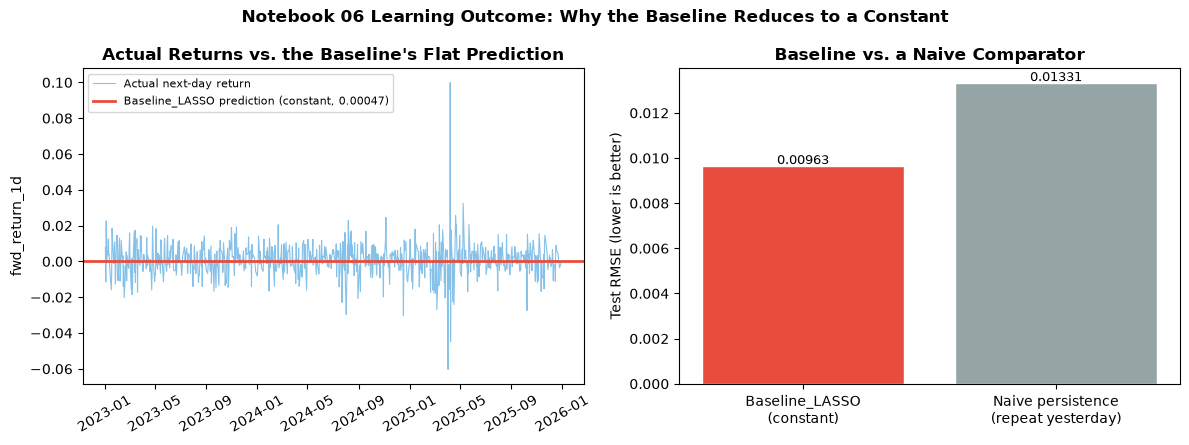

✓ Saved reports/figures/06_learning_outcome.png
  Left: the model's prediction is a flat line (every coefficient is zero, so it always predicts the training-split mean),
  while actual returns swing well above and below it every day.
  Right: Baseline_LASSO (RMSE 0.00963) still narrowly beats a naive 'repeat yesterday' guess (RMSE 0.01331) -- constant is not the same as useless, it's just not using any market-technical signal.


In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1: actual vs predicted over the test period -- makes "constant predictor" visible
ax = axes[0]
ax.plot(test['date'], y_test, color='#3498db', alpha=0.6, linewidth=0.8, label='Actual next-day return')
ax.axhline(pred_test[0], color='#e74c3c', linewidth=2, label=f'Baseline_LASSO prediction (constant, {pred_test[0]:.5f})')
ax.axhline(0, color='grey', linewidth=0.5, linestyle=':')
ax.set_ylabel('fwd_return_1d')
ax.set_title('Actual Returns vs. the Baseline\'s Flat Prediction', fontweight='bold')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=30)

# Panel 2: metrics vs two naive comparators, so the baseline's floor is visible in context
ax2 = axes[1]
naive_persistence_pred = test['return_lag1d'].values  # "today repeats tomorrow"
naive_persistence_rmse = float(np.sqrt(np.mean((y_test - naive_persistence_pred) ** 2)))
labels = ['Baseline_LASSO\n(constant)', 'Naive persistence\n(repeat yesterday)']
rmses = [metrics_test['RMSE'], naive_persistence_rmse]
colors = ['#e74c3c', '#95a5a6']
bars = ax2.bar(labels, rmses, color=colors, edgecolor='white')
for b, v in zip(bars, rmses):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.0001, f'{v:.5f}', ha='center', fontsize=9)
ax2.set_ylabel('Test RMSE (lower is better)')
ax2.set_title('Baseline vs. a Naive Comparator', fontweight='bold')

fig.suptitle('Notebook 06 Learning Outcome: Why the Baseline Reduces to a Constant', fontsize=12, fontweight='bold')
plt.tight_layout()
fig_path = ROOT / 'reports' / 'figures'
fig_path.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path / '06_learning_outcome.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved reports/figures/06_learning_outcome.png")
print(f"  Left: the model's prediction is a flat line (every coefficient is zero, so it always predicts the training-split mean),")
print(f"  while actual returns swing well above and below it every day.")
print(f"  Right: Baseline_LASSO (RMSE {metrics_test['RMSE']:.5f}) still narrowly beats a naive 'repeat yesterday' guess "
      f"(RMSE {naive_persistence_rmse:.5f}) -- constant is not the same as useless, it's just not using any market-technical signal.")

In [20]:
print('=' * 65)
print('PHASE 6 — BASELINE_LASSO v1.1 FREEZE: SUMMARY')
print('=' * 65)
print(f'\nBASELINE_LASSO')
print(f'  Features            : {len(MARKET_FEATURES)} (Market category only)')
print(f'  alpha_selected       : {baseline_lasso.alpha_}')
print(f'  All coefficients zero: {bool(np.allclose(baseline_lasso.coef_, 0))}')
print(f'  Intercept            : {baseline_lasso.intercept_}')
print(f'\nTEST METRICS')
for k, v in metrics_test.items():
    print(f'  {k:<10}: {v}')
print(f'\nFES INPUT VALIDATION : {fm_validation["validation_status"]} (FES v{fm_validation["fes_version"]})')
print(f'HISTORICAL REPRODUCTION EXACT: {REPRODUCTION_EXACT}')
print(f'SAVED MODEL VALIDATION: {saved_validation["validation_status"]}')
print(f'\nOUTPUTS  ->  models/baseline/, reports/baseline/')
print(f'\nNEXT: Notebook 07 — Model Evaluation (Event_LASSO, XGBoost, LightGBM vs. this baseline)')
print('=' * 65)

PHASE 6 — BASELINE_LASSO v1.1 FREEZE: SUMMARY

BASELINE_LASSO
  Features            : 27 (Market category only)
  alpha_selected       : 0.0018533887501907256
  All coefficients zero: True
  Intercept            : 0.00046584536225195564

TEST METRICS
  RMSE      : 0.009631061816812675
  MAE       : 0.006547931743181517
  R2        : -0.0015064059786111805
  Dir_Acc   : 0.5746666666666667

FES INPUT VALIDATION : PASS (FES v1.1)
HISTORICAL REPRODUCTION EXACT: True
SAVED MODEL VALIDATION: PASS

OUTPUTS  ->  models/baseline/, reports/baseline/

NEXT: Notebook 07 — Model Evaluation (Event_LASSO, XGBoost, LightGBM vs. this baseline)


## Section Summary & Handoff to Notebook 07

Notebook 06 trains and freezes `Baseline_LASSO` v1.1 from FES v1.1's 27 Market-category columns only. It validates the current FES contract, reproduces the dated FES v1.0 baseline exactly, and reloads the newly saved model, metadata, predictions, metrics, and validation record. Notebook 07 (`07_model_evaluation.ipynb`) must use the validated FES v1.1 matrix's full 92-feature set to train the event-enhanced candidates (`Event_LASSO`, `XGBoost`, `LightGBM`) and compare each against this baseline under `model_contract.md`'s promotion criteria.